In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
wti = pd.read_csv(
    'data/wti-daily.csv',
    parse_dates=['Date'],
).rename(columns={'Date':'date', 'Price':'oil'}).set_index(keys=['date']).sort_index()

wti

,oil
date,
1986-01-02,25.56
1986-01-03,26.00
1986-01-06,26.53
1986-01-07,25.85
1986-01-08,25.87
...,...
2021-12-14,70.57
2021-12-15,70.89
2021-12-16,72.34


In [46]:
ice = pd.read_csv(
    'data/ice-cream.csv',
    parse_dates=['DATE'],
).rename(columns={'DATE':'date', 'APU0000710411':'icecream'}).set_index(keys=['date']).sort_index()

ice

,icecream
date,
1980-01-01,1.755
1980-02-01,1.775
1980-03-01,1.718
1980-04-01,1.769
1980-05-01,1.822
...,...
2021-09-01,4.900
2021-10-01,4.952
2021-11-01,4.770


In [47]:
wti.dtypes

oil    float64
dtype: object

In [48]:
ice.dtypes

icecream    object
dtype: object

In [49]:
ice.loc[ice['icecream'].isnull()]

,icecream
date,


In [50]:
ice.loc[ice['icecream'] == '']

,icecream
date,


In [51]:
ice['icecream'].unique()

array(['1.755', '1.775', '1.718', '1.769', '1.822', '1.832', '1.831',
       '1.873', '1.825', '1.879', '1.878', '1.920', '1.938', '2.019',
       '1.992', '2.024', '2.008', '2.006', '2.014', '2.042', '2.032',
       '2.028', '2.064', '2.128', '2.075', '2.061', '2.089', '2.043',
       '2.060', '2.092', '2.095', '2.105', '2.136', '2.187', '2.163',
       '2.179', '2.139', '2.091', '2.107', '2.140', '2.141', '2.122',
       '2.135', '2.193', '2.249', '2.214', '2.184', '2.189', '2.191',
       '2.171', '2.210', '2.203', '2.212', '2.232', '2.301', '2.259',
       '2.223', '2.231', '2.284', '2.291', '2.290', '2.312', '2.276',
       '2.293', '2.273', '2.345', '2.347', '2.294', '2.317', '2.346',
       '2.331', '2.382', '2.368', '2.325', '2.369', '2.319', '2.360',
       '2.377', '2.397', '2.405', '.', '2.468', '2.447', '2.438', '2.481',
       '2.428', '2.467', '2.482', '2.470', '2.492', '2.449', '2.495',
       '2.475', '2.406', '2.430', '2.457', '2.432', '2.443', '2.442',
       '2.446',

In [52]:
ice.loc[ice['icecream'] == '.', 'icecream'] = np.nan

In [53]:
ice = ice.dropna()

In [54]:
ice.loc[:, 'icecream'] = ice['icecream'].astype(float)

In [55]:
ice.dtypes

icecream    object
dtype: object

In [60]:
ice.loc[:, 'icecream'] = ice['icecream'].astype(float)

In [62]:
ice.dtypes

icecream    float64
dtype: object

In [64]:
mile = pd.read_csv(
    'data/miles-traveled.csv',
    parse_dates=['DATE'],
).rename(columns={'DATE': 'date', 'TRFVOLUSM227NFWA': 'miles'}).set_index(keys=['date']).sort_index()

mile

,miles
date,
1970-01-01,80173.0
1970-02-01,77442.0
1970-03-01,90223.0
1970-04-01,89956.0
1970-05-01,97972.0
...,...
2021-08-01,287397.0
2021-09-01,277979.0
2021-10-01,285760.0


In [65]:
mile.dtypes

miles    float64
dtype: object

In [66]:
df = pd.concat(objs=[wti, ice, mile], axis=1)
df

,oil,icecream,miles
date,,,
1970-01-01,NaN,NaN,80173.0
1970-02-01,NaN,NaN,77442.0
1970-03-01,NaN,NaN,90223.0
1970-04-01,NaN,NaN,89956.0
1970-05-01,NaN,NaN,97972.0
...,...,...,...
2021-12-15,70.89,NaN,NaN
2021-12-16,72.34,NaN,NaN
2021-12-17,70.93,NaN,NaN


In [67]:
df = df.dropna()

In [68]:
df

,oil,icecream,miles
date,,,
1986-04-01,11.13,2.382,150277.0
1986-05-01,13.80,2.368,160459.0
1986-07-01,12.39,2.369,171114.0
1986-08-01,11.56,2.319,173977.0
1986-10-01,15.23,2.377,159434.0
...,...,...,...
2021-07-01,75.33,4.943,296475.0
2021-09-01,68.63,4.900,277979.0
2021-10-01,76.01,4.952,285760.0


In [69]:
df.corr()

,oil,icecream,miles
oil,1.000000,0.777347,0.645250
icecream,0.777347,1.000000,0.818383
miles,0.645250,0.818383,1.000000


<Axes: xlabel='oil', ylabel='icecream'>

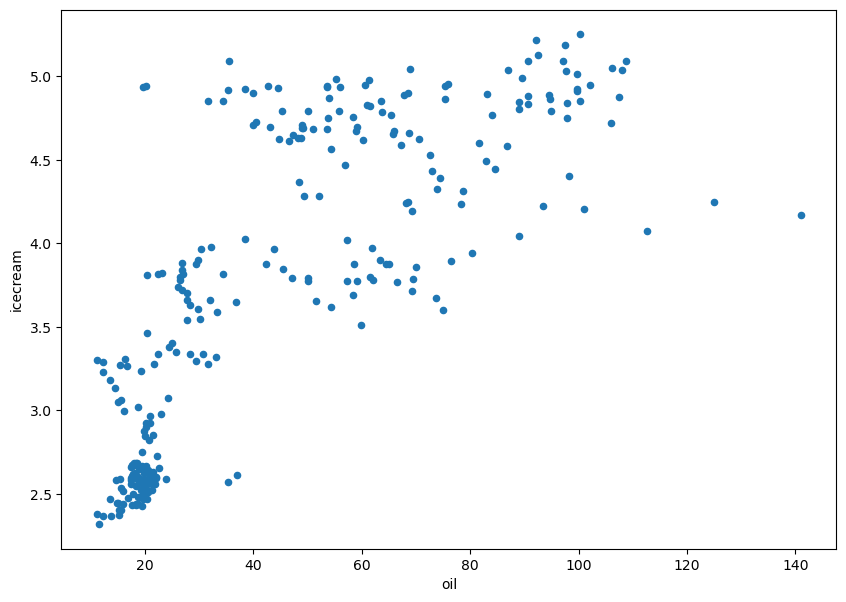

In [72]:
df.plot.scatter(x='oil', y='icecream', figsize=(10, 7))

<Axes: xlabel='oil', ylabel='miles'>

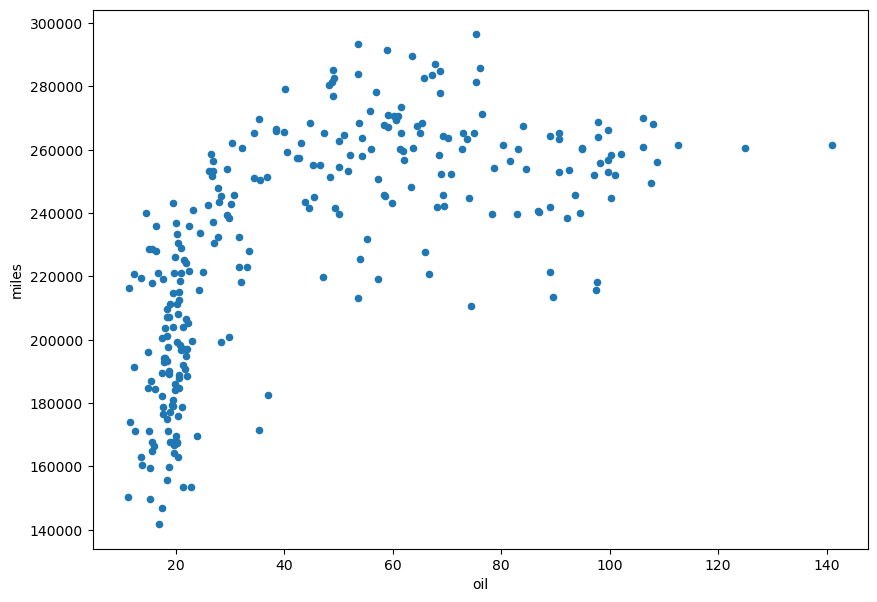

In [73]:
df.plot.scatter(x='oil', y='miles', figsize=(10, 7))

In [75]:
from pandas.plotting import scatter_matrix

array([[<Axes: xlabel='oil', ylabel='oil'>,
        <Axes: xlabel='icecream', ylabel='oil'>,
        <Axes: xlabel='miles', ylabel='oil'>],
       [<Axes: xlabel='oil', ylabel='icecream'>,
        <Axes: xlabel='icecream', ylabel='icecream'>,
        <Axes: xlabel='miles', ylabel='icecream'>],
       [<Axes: xlabel='oil', ylabel='miles'>,
        <Axes: xlabel='icecream', ylabel='miles'>,
        <Axes: xlabel='miles', ylabel='miles'>]], dtype=object)

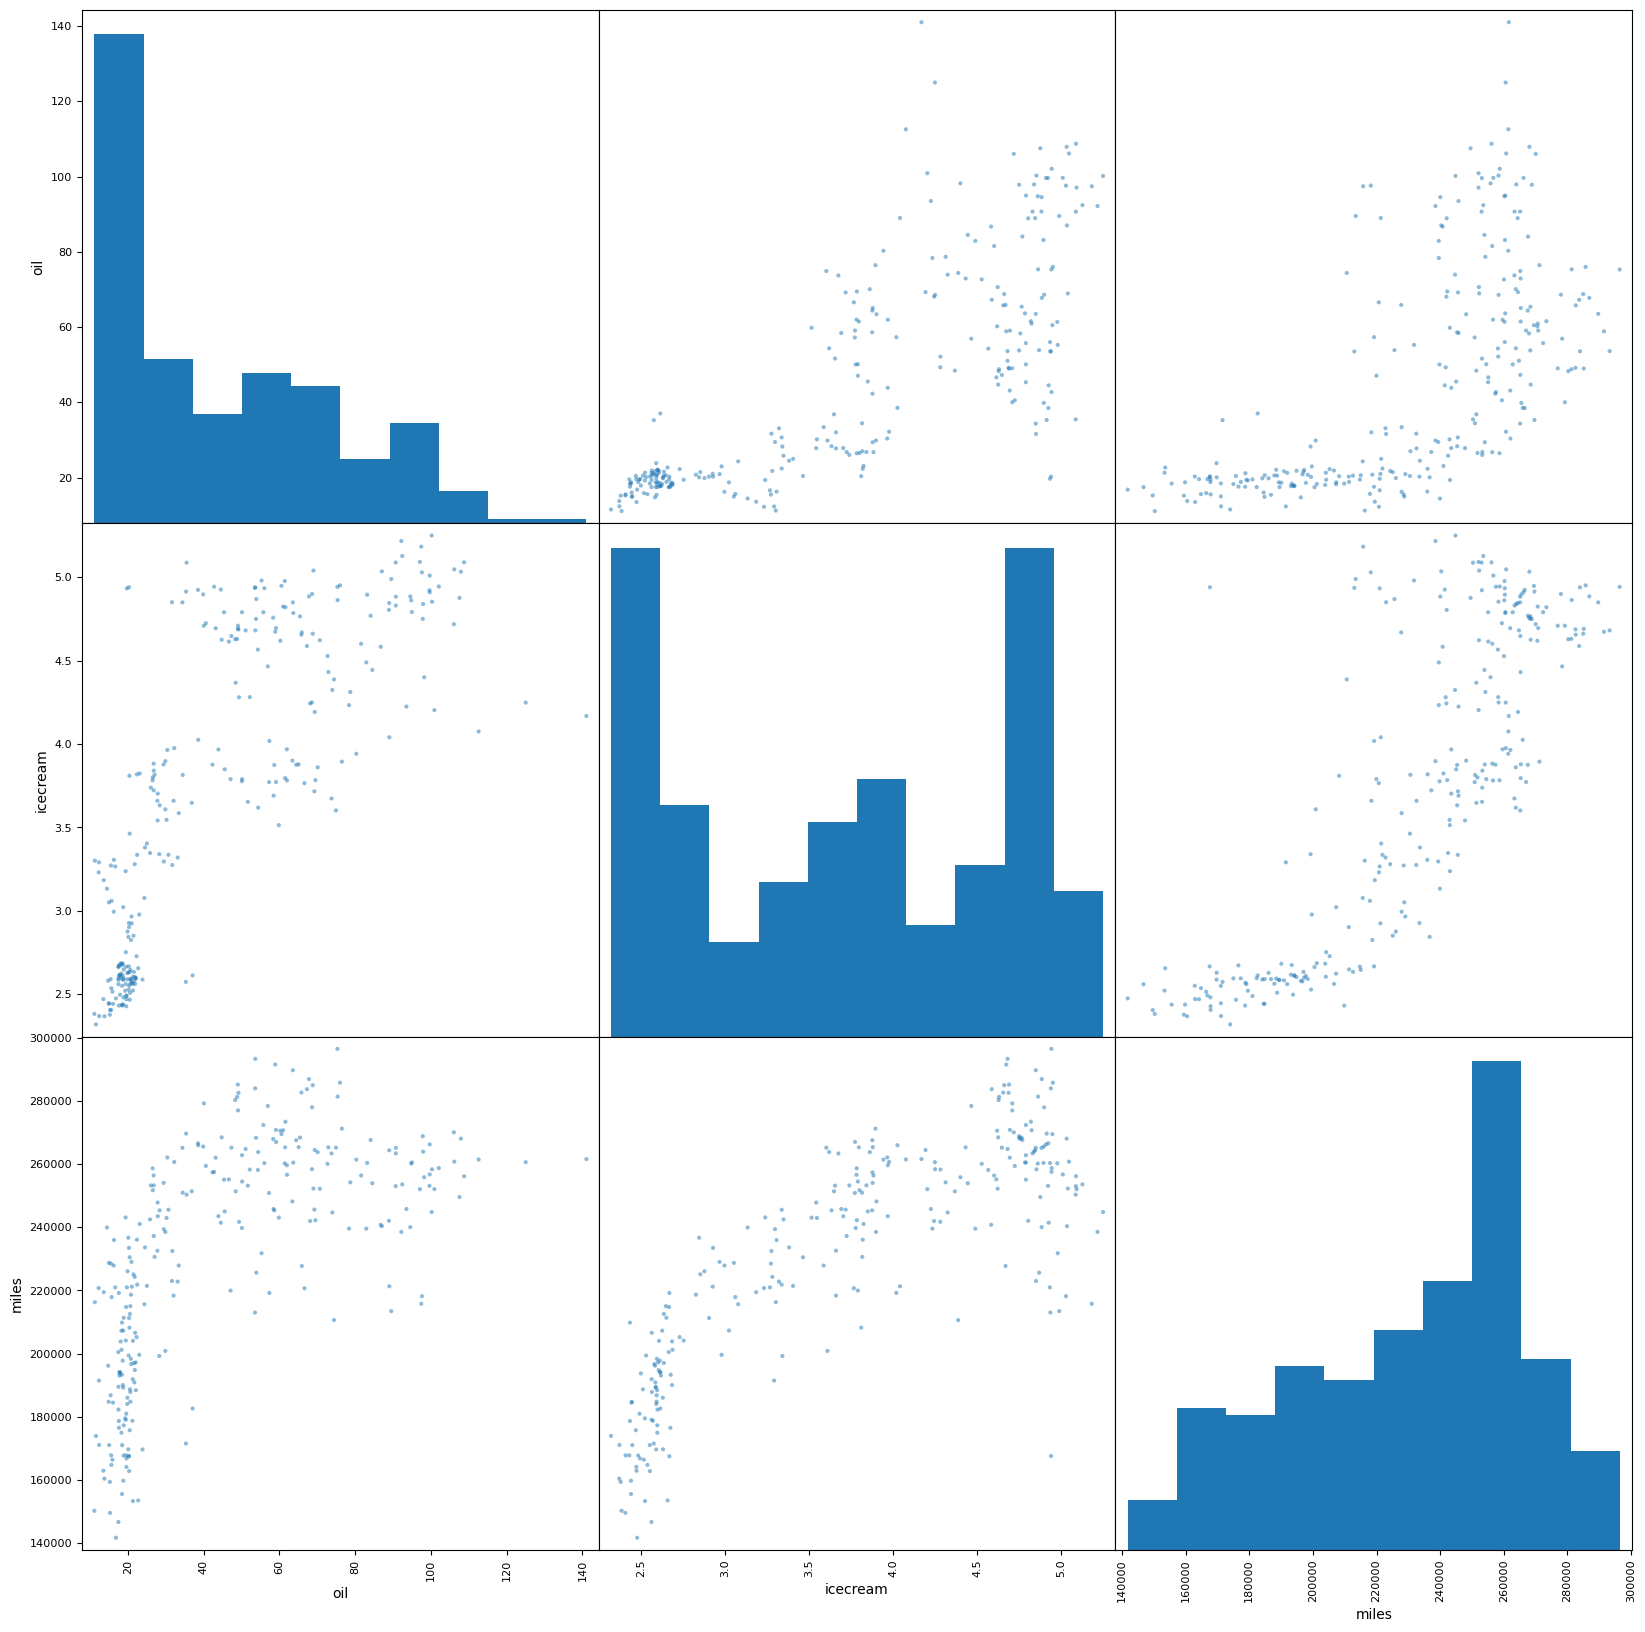

In [78]:
scatter_matrix(df, figsize=(20, 20))

In [79]:
# 46.1

In [80]:
df

,oil,icecream,miles
date,,,
1986-04-01,11.13,2.382,150277.0
1986-05-01,13.80,2.368,160459.0
1986-07-01,12.39,2.369,171114.0
1986-08-01,11.56,2.319,173977.0
1986-10-01,15.23,2.377,159434.0
...,...,...,...
2021-07-01,75.33,4.943,296475.0
2021-09-01,68.63,4.900,277979.0
2021-10-01,76.01,4.952,285760.0


In [81]:
df = df.reset_index()

In [82]:
df

,date,oil,icecream,miles
0,1986-04-01,11.13,2.382,150277.0
1,1986-05-01,13.80,2.368,160459.0
2,1986-07-01,12.39,2.369,171114.0
3,1986-08-01,11.56,2.319,173977.0
4,1986-10-01,15.23,2.377,159434.0
...,...,...,...,...
270,2021-07-01,75.33,4.943,296475.0
271,2021-09-01,68.63,4.900,277979.0
272,2021-10-01,76.01,4.952,285760.0
273,2021-11-01,84.08,4.770,267647.0


In [83]:
df['month'] = df['date'].dt.month

In [84]:
df

,date,oil,icecream,miles,month
0,1986-04-01,11.13,2.382,150277.0,4
1,1986-05-01,13.80,2.368,160459.0,5
2,1986-07-01,12.39,2.369,171114.0,7
3,1986-08-01,11.56,2.319,173977.0,8
4,1986-10-01,15.23,2.377,159434.0,10
...,...,...,...,...,...
270,2021-07-01,75.33,4.943,296475.0,7
271,2021-09-01,68.63,4.900,277979.0,9
272,2021-10-01,76.01,4.952,285760.0,10
273,2021-11-01,84.08,4.770,267647.0,11


In [85]:
df = df.set_index(keys=['date']).sort_index()

In [86]:
df.corr()

,oil,icecream,miles,month
oil,1.000000,0.777347,0.645250,0.006616
icecream,0.777347,1.000000,0.818383,-0.003985
miles,0.645250,0.818383,1.000000,0.079290
month,0.006616,-0.003985,0.079290,1.000000


In [87]:
# 46.2

<Axes: xlabel='oil', ylabel='miles'>

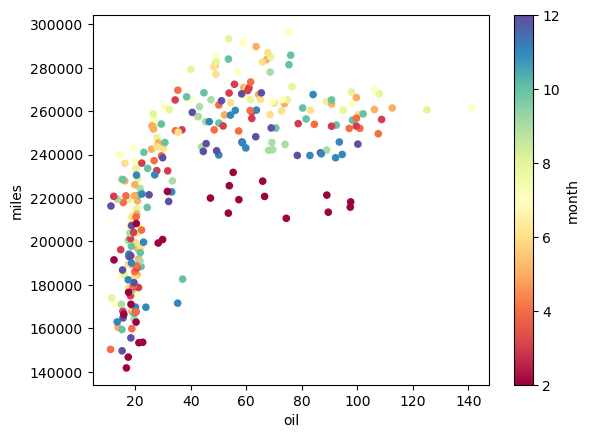

In [93]:
df.plot.scatter(x='oil', y='miles', c='month', colormap='Spectral')

In [94]:
# 46.3

In [96]:
wti

,oil
date,
1986-01-02,25.56
1986-01-03,26.00
1986-01-06,26.53
1986-01-07,25.85
1986-01-08,25.87
...,...
2021-12-14,70.57
2021-12-15,70.89
2021-12-16,72.34


In [97]:
df = wti.copy()

In [98]:
df = df.reset_index()

In [101]:
df.loc[~df['date'].dt.is_month_end]

,date,oil
0,1986-01-02,25.56
1,1986-01-03,26.00
2,1986-01-06,26.53
3,1986-01-07,25.85
4,1986-01-08,25.87
...,...,...
9059,2021-12-14,70.57
9060,2021-12-15,70.89
9061,2021-12-16,72.34
9062,2021-12-17,70.93


In [102]:
df.loc[df['date'].dt.is_month_end]

,date,oil
21,1986-01-31,18.95
40,1986-02-28,13.23
60,1986-03-31,10.25
82,1986-04-30,13.38
124,1986-06-30,12.80
...,...,...
8902,2021-04-30,63.50
8944,2021-06-30,73.52
8987,2021-08-31,68.43
9008,2021-09-30,75.22
